# FAFB Block Statistical Analysis and Representative Block Selection

This notebook scans all 3D microscopy blocks and computes:

- intensity mean, variance, standard deviation and robust spread;
- histogram entropy;
- 3D gradient energy;
- high-frequency residual energy;
- Laplacian energy;
- percentile ranks across all blocks;
- a composite complexity score.

It then selects four representative blocks for the Gaussian-versus-SIREN
compression experiment:

1. **Simple:** low variance, entropy, gradient and high-frequency energy.
2. **Typical:** near the median of all statistics.
3. **Complex:** high variance, entropy and high-frequency content.
4. **Edge-rich:** very high gradient and Laplacian energy.

The selected blocks should be fixed before training either representation.

## Installation

```bash
pip install numpy pandas scipy matplotlib h5py zarr tqdm
```

In [40]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterator, Optional
import json
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
from tqdm.auto import tqdm

## Configuration

In [41]:
# Input modes:
#   "h5"         -> one HDF5 file containing a 3D dataset
#   "zarr"       -> one Zarr array/group
#   "npy_volume" -> one large .npy volume, loaded with memory mapping
#   "blocks"     -> directory containing separate .npy blocks
#   "tif"        -> directory containing separate .tif blocks

INPUT_MODE = "tif"
# Must be the BLOCKS DIRECTORY, not a single block file -- "tif" mode treats
# every file matching TIF_GLOB inside this directory as one separate block
# (mirrors "blocks" mode's handling of .npy files). Pointing this at a single
# .tif file (as it was before) only ever yields 1 block, which is why
# selecting 4 representative blocks failed downstream.
INPUT_PATH = Path("/root/project/fafb_pilot/dataset/fafb/blocks")

H5_DATASET = "raw"
ZARR_ARRAY_PATH = ""
BLOCK_GLOB = "*.npy"
# Intensity blocks only -- the same directory also holds segment_*.tif
# (instance-segmentation label volumes), which must not be mixed into
# intensity statistics.
TIF_GLOB = "image_*.tif"

# All shapes use z, y, x order.
BLOCK_SHAPE = (64, 64, 64)
BLOCK_STRIDE = (64, 64, 64)

# None processes all blocks. The blocks directory has 262,144 files -- that
# will take a long time to scan in full (per-block gradient/Laplacian/entropy
# computation each). Consider setting this to a few thousand for a first pass.
MAX_BLOCKS = None

# "dtype", "percentile", or "none"
NORMALIZATION = "dtype"
LOW_PERCENTILE = 0.5
HIGH_PERCENTILE = 99.5
NORMALIZATION_SAMPLE_BLOCKS = 128

HISTOGRAM_BINS = 256
GAUSSIAN_BLUR_SIGMA = 1.0
RANDOM_SEED = 20260721

OUTPUT_DIR = Path("./fafb_block_statistics_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output:", OUTPUT_DIR.resolve())

Output: /root/project/fafb_pilot/code/renderer/scratch_gs/data_processor/fafb_block_statistics_output


## Lazy loaders and block iterator

In [42]:
@dataclass
class BlockRecord:
    block_id: str
    origin_z: int
    origin_y: int
    origin_x: int
    valid_shape: tuple[int, int, int]
    padded: bool
    block: np.ndarray


class VolumeSource:
    def __init__(self, mode: str, path: Path):
        self.mode = mode
        self.path = Path(path)
        self.handle = None
        self.array = None
        self.block_paths: list[Path] = []

    def open(self):
        if self.mode == "h5":
            import h5py
            self.handle = h5py.File(self.path, "r")
            if H5_DATASET not in self.handle:
                raise KeyError(
                    f"Dataset {H5_DATASET!r} not found. "
                    f"Available: {list(self.handle.keys())}"
                )
            self.array = self.handle[H5_DATASET]

        elif self.mode == "zarr":
            import zarr
            root = zarr.open(str(self.path), mode="r")
            self.array = root if ZARR_ARRAY_PATH == "" else root[ZARR_ARRAY_PATH]

        elif self.mode == "npy_volume":
            self.array = np.load(self.path, mmap_mode="r")

        elif self.mode == "blocks":
            self.block_paths = sorted(self.path.glob(BLOCK_GLOB))
            if not self.block_paths:
                raise FileNotFoundError(
                    f"No files matching {BLOCK_GLOB!r} in {self.path}"
                )

        elif self.mode == "tif":
            # Directory containing separate .tif blocks (matches "blocks"
            # mode's handling of .npy files) -- NOT a single .tif file read
            # as one giant volume. self.path must be the blocks directory.
            self.block_paths = sorted(self.path.glob(TIF_GLOB))
            if not self.block_paths:
                raise FileNotFoundError(
                    f"No files matching {TIF_GLOB!r} in {self.path}"
                )

        else:
            raise ValueError(f"Unsupported mode: {self.mode}")

        if self.mode not in ("blocks", "tif") and getattr(self.array, "ndim", None) != 3:
            raise ValueError(f"Expected 3D input, got shape {self.array.shape}")

        return self

    def close(self):
        if self.handle is not None:
            self.handle.close()

    @property
    def shape(self):
        if self.mode == "blocks":
            return tuple(np.load(self.block_paths[0], mmap_mode="r").shape)
        if self.mode == "tif":
            import tifffile as tiff
            return tuple(np.asarray(tiff.imread(self.block_paths[0])).shape)
        return tuple(self.array.shape)

    @property
    def dtype(self):
        if self.mode == "blocks":
            return np.load(self.block_paths[0], mmap_mode="r").dtype
        if self.mode == "tif":
            import tifffile as tiff
            return np.asarray(tiff.imread(self.block_paths[0])).dtype
        return np.dtype(self.array.dtype)


def pad_block(block: np.ndarray, target_shape: tuple[int, int, int]):
    valid_shape = tuple(int(v) for v in block.shape)
    padded = valid_shape != target_shape
    if not padded:
        return np.asarray(block), valid_shape, False

    pad_width = [
        (0, target_shape[d] - valid_shape[d])
        for d in range(3)
    ]
    return np.pad(block, pad_width, mode="edge"), valid_shape, True


def iter_blocks(
    source: VolumeSource,
    block_shape: tuple[int, int, int],
    stride: tuple[int, int, int],
    max_blocks: Optional[int] = None,
) -> Iterator[BlockRecord]:

    if source.mode in ("blocks", "tif"):
        if source.mode == "tif":
            import tifffile as tiff

        for i, path in enumerate(source.block_paths):
            if max_blocks is not None and i >= max_blocks:
                break

            block = np.load(path) if source.mode == "blocks" else np.asarray(tiff.imread(path))
            block, valid_shape, padded = pad_block(block, block_shape)

            yield BlockRecord(
                block_id=path.stem,
                origin_z=-1,
                origin_y=-1,
                origin_x=-1,
                valid_shape=valid_shape,
                padded=padded,
                block=block,
            )
        return

    dz, dy, dx = source.shape
    bz, by, bx = block_shape
    sz, sy, sx = stride

    count = 0
    for z0 in range(0, dz, sz):
        for y0 in range(0, dy, sy):
            for x0 in range(0, dx, sx):
                if max_blocks is not None and count >= max_blocks:
                    return

                raw = np.asarray(
                    source.array[
                        z0:min(z0 + bz, dz),
                        y0:min(y0 + by, dy),
                        x0:min(x0 + bx, dx),
                    ]
                )
                block, valid_shape, padded = pad_block(raw, block_shape)

                yield BlockRecord(
                    block_id=f"z{z0:07d}_y{y0:07d}_x{x0:07d}",
                    origin_z=z0,
                    origin_y=y0,
                    origin_x=x0,
                    valid_shape=valid_shape,
                    padded=padded,
                    block=block,
                )
                count += 1

## Dataset-level normalization

In [43]:
def estimate_percentile_range(source: VolumeSource):
    rng = np.random.default_rng(RANDOM_SEED)
    sampled_blocks = []

    for record in iter_blocks(
        source,
        BLOCK_SHAPE,
        BLOCK_STRIDE,
        max_blocks=NORMALIZATION_SAMPLE_BLOCKS * 4,
    ):
        sampled_blocks.append(record.block)

    if not sampled_blocks:
        raise RuntimeError("No blocks available for normalization.")

    if len(sampled_blocks) > NORMALIZATION_SAMPLE_BLOCKS:
        ids = rng.choice(
            len(sampled_blocks),
            size=NORMALIZATION_SAMPLE_BLOCKS,
            replace=False,
        )
        sampled_blocks = [sampled_blocks[i] for i in ids]

    sampled_values = np.concatenate([
        block.reshape(-1)[::max(1, block.size // 4096)]
        for block in sampled_blocks
    ]).astype(np.float32)

    low = float(np.percentile(sampled_values, LOW_PERCENTILE))
    high = float(np.percentile(sampled_values, HIGH_PERCENTILE))

    if high <= low:
        raise ValueError("Degenerate normalization range.")
    return low, high


def get_normalization_range(source: VolumeSource):
    if NORMALIZATION == "none":
        return None

    if NORMALIZATION == "dtype":
        if np.issubdtype(source.dtype, np.integer):
            info = np.iinfo(source.dtype)
            return float(info.min), float(info.max)

        first = next(
            iter_blocks(source, BLOCK_SHAPE, BLOCK_STRIDE, max_blocks=1)
        ).block.astype(np.float32)
        return float(first.min()), float(first.max())

    if NORMALIZATION == "percentile":
        return estimate_percentile_range(source)

    raise ValueError(f"Unknown normalization: {NORMALIZATION}")


def normalize_block(block: np.ndarray, value_range):
    volume = block.astype(np.float32)
    if value_range is None:
        return volume

    low, high = value_range
    volume = (volume - low) / (high - low)
    return np.clip(volume, 0.0, 1.0)

## Block statistics

In [44]:
def entropy_from_histogram(volume: np.ndarray, bins: int = 256) -> float:
    values = volume[np.isfinite(volume)]
    if values.size == 0:
        return float("nan")

    vmin = float(values.min())
    vmax = float(values.max())
    if vmax <= vmin:
        return 0.0

    hist, _ = np.histogram(values, bins=bins, range=(vmin, vmax))
    probabilities = hist.astype(np.float64)
    probabilities /= probabilities.sum()
    probabilities = probabilities[probabilities > 0]
    return float(-np.sum(probabilities * np.log2(probabilities)))


def block_statistics(volume: np.ndarray, record: BlockRecord) -> dict:
    volume = np.asarray(volume, dtype=np.float32)

    mean = float(volume.mean())
    median = float(np.median(volume))
    variance = float(volume.var())
    std = float(volume.std())
    mad = float(np.median(np.abs(volume - median)))

    gz, gy, gx = np.gradient(volume)
    grad = np.sqrt(gx * gx + gy * gy + gz * gz)

    blurred = ndimage.gaussian_filter(
        volume,
        sigma=GAUSSIAN_BLUR_SIGMA,
    )
    high_frequency = volume - blurred
    laplacian = ndimage.laplace(volume)

    valid_voxels = int(np.prod(record.valid_shape))
    total_voxels = int(volume.size)

    return {
        "block_id": record.block_id,
        "origin_z": record.origin_z,
        "origin_y": record.origin_y,
        "origin_x": record.origin_x,
        "valid_z": record.valid_shape[0],
        "valid_y": record.valid_shape[1],
        "valid_x": record.valid_shape[2],
        "padded": record.padded,
        "valid_fraction": valid_voxels / total_voxels,
        "mean": mean,
        "median": median,
        "variance": variance,
        "std": std,
        "mad": mad,
        "entropy": entropy_from_histogram(volume, HISTOGRAM_BINS),
        "mean_gradient": float(grad.mean()),
        "gradient_p90": float(np.percentile(grad, 90)),
        "gradient_p99": float(np.percentile(grad, 99)),
        "hf_l1": float(np.mean(np.abs(high_frequency))),
        "hf_l2": float(np.mean(high_frequency ** 2)),
        "laplacian_l1": float(np.mean(np.abs(laplacian))),
        "laplacian_l2": float(np.mean(laplacian ** 2)),
        "minimum": float(volume.min()),
        "maximum": float(volume.max()),
    }

## Scan all blocks

In [45]:
source = VolumeSource(INPUT_MODE, INPUT_PATH).open()

try:
    normalization_range = get_normalization_range(source)
    print("Source shape:", source.shape)
    print("Source dtype:", source.dtype)
    print("Normalization range:", normalization_range)

    rows = []
    started = time.perf_counter()

    for record in tqdm(
        iter_blocks(
            source,
            BLOCK_SHAPE,
            BLOCK_STRIDE,
            MAX_BLOCKS,
        ),
        desc="Computing block statistics",
    ):
        normalized = normalize_block(record.block, normalization_range)
        rows.append(block_statistics(normalized, record))

    elapsed = time.perf_counter() - started

finally:
    source.close()

statistics_df = pd.DataFrame(rows)

if statistics_df.empty:
    raise RuntimeError("No blocks were processed.")

statistics_df.to_csv(
    OUTPUT_DIR / "all_block_statistics.csv",
    index=False,
)

print(f"Processed {len(statistics_df):,} blocks in {elapsed:.2f} seconds.")
statistics_df.head()

Source shape: (64, 64, 64)
Source dtype: uint8
Normalization range: (0.0, 255.0)


Computing block statistics: 0it [00:00, ?it/s]

Processed 262,144 blocks in 5120.26 seconds.


,block_id,origin_z,origin_y,origin_x,valid_z,valid_y,valid_x,padded,valid_fraction,mean,...,entropy,mean_gradient,gradient_p90,gradient_p99,hf_l1,hf_l2,laplacian_l1,laplacian_l2,minimum,maximum
0,image_z0_y0_x0,-1,-1,-1,64,64,64,False,1.0,0.583297,...,7.670163,0.158585,0.293155,0.403888,0.098987,0.015538,0.372084,0.225815,0.0,1.000000
1,image_z0_y0_x1,-1,-1,-1,64,64,64,False,1.0,0.591439,...,7.610772,0.144165,0.279534,0.398077,0.088126,0.012902,0.335287,0.192204,0.0,1.000000
2,image_z0_y0_x10,-1,-1,-1,64,64,64,False,1.0,0.496045,...,7.876428,0.167185,0.293004,0.427346,0.102996,0.016536,0.395269,0.249360,0.0,1.000000
3,image_z0_y0_x11,-1,-1,-1,64,64,64,False,1.0,0.502269,...,7.882138,0.159026,0.288035,0.427782,0.096926,0.014728,0.367185,0.216620,0.0,1.000000
4,image_z0_y0_x12,-1,-1,-1,64,64,64,False,1.0,0.490205,...,7.865396,0.155300,0.293588,0.438320,0.089348,0.012508,0.332149,0.178061,0.0,0.996078


## Percentile ranks and composite scores

In [46]:
percentile_features = [
    "variance",
    "entropy",
    "mean_gradient",
    "gradient_p90",
    "hf_l1",
    "laplacian_l1",
]

for feature in percentile_features:
    statistics_df[f"{feature}_percentile"] = (
        statistics_df[feature].rank(method="average", pct=True) * 100.0
    )

statistics_df["complexity_score"] = statistics_df[
    [
        "variance_percentile",
        "entropy_percentile",
        "mean_gradient_percentile",
        "hf_l1_percentile",
    ]
].mean(axis=1)

statistics_df["edge_score"] = statistics_df[
    [
        "mean_gradient_percentile",
        "gradient_p90_percentile",
        "laplacian_l1_percentile",
        "hf_l1_percentile",
    ]
].mean(axis=1)

statistics_df.to_csv(
    OUTPUT_DIR / "all_block_statistics_with_percentiles.csv",
    index=False,
)

statistics_df.describe().T

,count,mean,std,min,25%,50%,75%,max
origin_z,262144.0,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
origin_y,262144.0,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
origin_x,262144.0,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
valid_z,262144.0,64.000000,0.000000,64.000000,64.000000,64.000000,64.000000,64.000000
valid_y,262144.0,64.000000,0.000000,64.000000,64.000000,64.000000,64.000000,64.000000
valid_x,262144.0,64.000000,0.000000,64.000000,64.000000,64.000000,64.000000,64.000000
valid_fraction,262144.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,262144.0,0.521545,0.131689,0.000000,0.520150,0.549239,0.578126,0.834833
median,262144.0,0.549720,0.156636,0.000000,0.529412,0.580392,0.631373,0.878431
variance,262144.0,0.066276,0.017248,0.000000,0.062469,0.071225,0.076024,0.129761


## Distribution plots

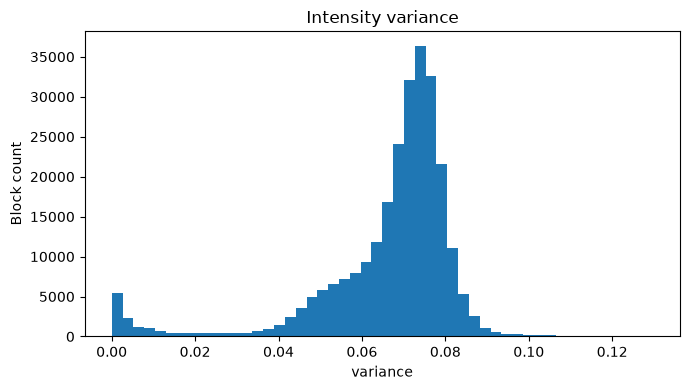

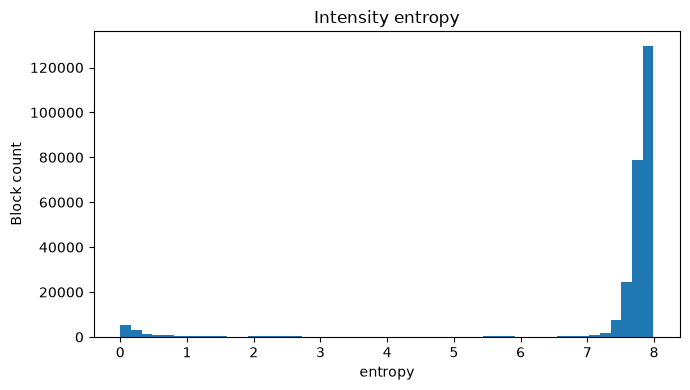

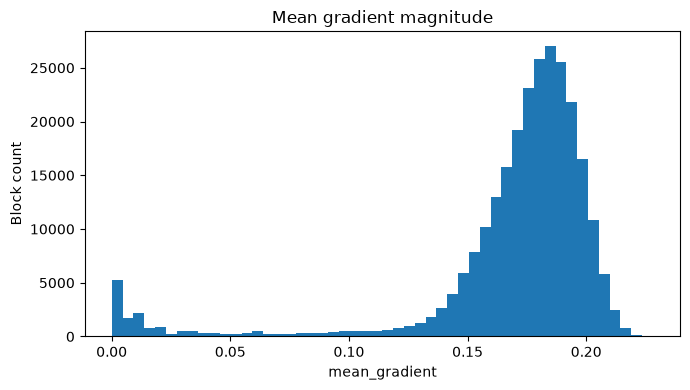

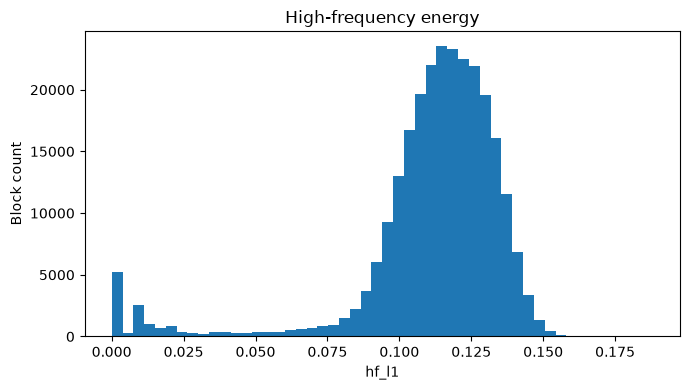

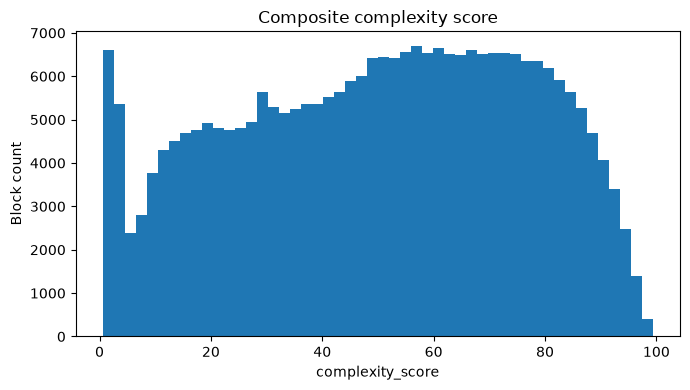

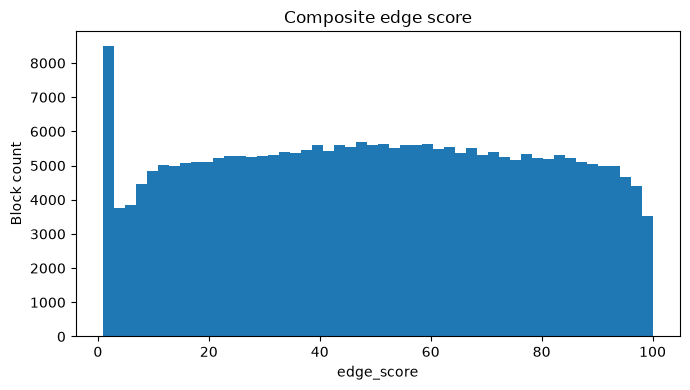

In [47]:
plot_features = [
    ("variance", "Intensity variance"),
    ("entropy", "Intensity entropy"),
    ("mean_gradient", "Mean gradient magnitude"),
    ("hf_l1", "High-frequency energy"),
    ("complexity_score", "Composite complexity score"),
    ("edge_score", "Composite edge score"),
]

for feature, title in plot_features:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(statistics_df[feature].dropna(), bins=50)
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Block count")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"hist_{feature}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

## Select four representative blocks

In [48]:
TARGETS = {
    "simple": {
        "variance_percentile": 10.0,
        "entropy_percentile": 10.0,
        "mean_gradient_percentile": 10.0,
        "hf_l1_percentile": 10.0,
    },
    "typical": {
        "variance_percentile": 50.0,
        "entropy_percentile": 50.0,
        "mean_gradient_percentile": 50.0,
        "hf_l1_percentile": 50.0,
    },
    "complex": {
        "variance_percentile": 90.0,
        "entropy_percentile": 90.0,
        "mean_gradient_percentile": 80.0,
        "hf_l1_percentile": 90.0,
    },
    "edge_rich": {
        "variance_percentile": 70.0,
        "entropy_percentile": 80.0,
        "mean_gradient_percentile": 95.0,
        "gradient_p90_percentile": 95.0,
        "laplacian_l1_percentile": 95.0,
        "hf_l1_percentile": 90.0,
    },
}


def profile_distance(frame: pd.DataFrame, target: dict[str, float]) -> pd.Series:
    squared = []
    for feature, target_value in target.items():
        squared.append((frame[feature] - target_value) ** 2)
    return np.sqrt(pd.concat(squared, axis=1).mean(axis=1))


candidates = statistics_df[
    (statistics_df["padded"] == False) &
    (statistics_df["valid_fraction"] == 1.0)
].copy()

if len(candidates) < 4:
    raise RuntimeError("Fewer than four complete candidate blocks are available.")

selected_rows = []
used_ids = set()

for category, target in TARGETS.items():
    distances = profile_distance(candidates, target)
    ordered = candidates.assign(distance=distances).sort_values("distance")

    chosen = None
    for _, row in ordered.iterrows():
        if row["block_id"] not in used_ids:
            chosen = row
            break

    if chosen is None:
        raise RuntimeError(f"Could not select a unique block for {category}")

    used_ids.add(chosen["block_id"])
    selected_rows.append({
        "category": category,
        **chosen.to_dict(),
    })

selected_df = pd.DataFrame(selected_rows)
selected_df.to_csv(
    OUTPUT_DIR / "selected_representative_blocks.csv",
    index=False,
)

columns_to_show = [
    "category",
    "block_id",
    "origin_z",
    "origin_y",
    "origin_x",
    "variance_percentile",
    "entropy_percentile",
    "mean_gradient_percentile",
    "hf_l1_percentile",
    "laplacian_l1_percentile",
    "complexity_score",
    "edge_score",
]

selected_df[columns_to_show]

,category,block_id,origin_z,origin_y,origin_x,variance_percentile,entropy_percentile,mean_gradient_percentile,hf_l1_percentile,laplacian_l1_percentile,complexity_score,edge_score
0,simple,image_z56_y53_x37,-1,-1,-1,10.094833,9.810638,10.230255,9.687424,10.406876,9.955788,9.644413
1,typical,image_z38_y46_x62,-1,-1,-1,49.550629,49.465561,48.265839,50.825119,45.264435,49.526787,50.961065
2,complex,image_z14_y11_x17,-1,-1,-1,91.127014,90.874100,79.528427,90.377426,85.276031,87.976742,83.585072
3,edge_rich,image_z11_y27_x15,-1,-1,-1,69.870377,80.016708,95.807648,88.550186,93.215561,83.561230,92.439938


## Reload and save selected blocks

In [49]:
def read_selected_block(source: VolumeSource, row: pd.Series) -> np.ndarray:
    if source.mode in ("blocks", "tif"):
        ext = ".npy" if source.mode == "blocks" else ".tif"
        path = source.path / f"{row['block_id']}{ext}"
        if not path.exists():
            matches = list(source.path.glob(f"{row['block_id']}*"))
            if not matches:
                raise FileNotFoundError(f"Cannot locate {row['block_id']}")
            path = matches[0]

        if source.mode == "blocks":
            block = np.load(path)
        else:
            import tifffile as tiff
            block = np.asarray(tiff.imread(path))

        block, _, _ = pad_block(block, BLOCK_SHAPE)
        return block

    z0 = int(row["origin_z"])
    y0 = int(row["origin_y"])
    x0 = int(row["origin_x"])
    bz, by, bx = BLOCK_SHAPE

    block = np.asarray(
        source.array[
            z0:z0 + bz,
            y0:y0 + by,
            x0:x0 + bx,
        ]
    )
    block, _, _ = pad_block(block, BLOCK_SHAPE)
    return block


selected_dir = OUTPUT_DIR / "selected_blocks"
selected_dir.mkdir(parents=True, exist_ok=True)

source = VolumeSource(INPUT_MODE, INPUT_PATH).open()
try:
    normalization_range = get_normalization_range(source)

    for _, row in selected_df.iterrows():
        raw_block = read_selected_block(source, row)
        normalized_block = normalize_block(raw_block, normalization_range)

        category = row["category"]
        np.save(selected_dir / f"{category}_raw.npy", raw_block)
        np.save(selected_dir / f"{category}_normalized.npy", normalized_block)

finally:
    source.close()

print("Saved selected blocks to:", selected_dir.resolve())

Saved selected blocks to: /root/project/fafb_pilot/code/renderer/scratch_gs/data_processor/fafb_block_statistics_output/selected_blocks


## Preview selected blocks

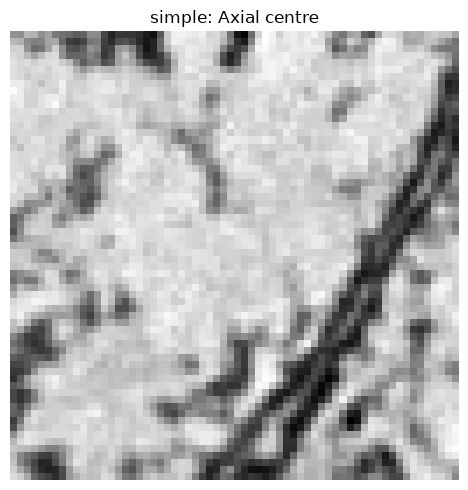

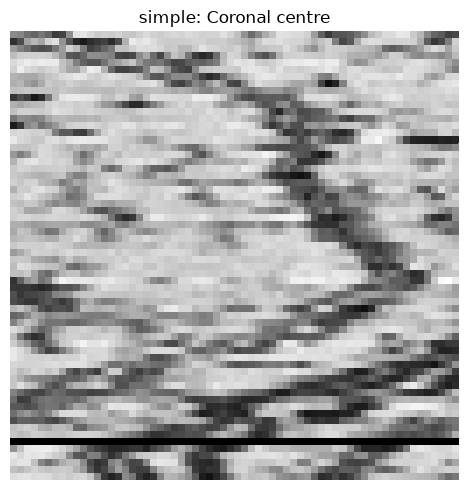

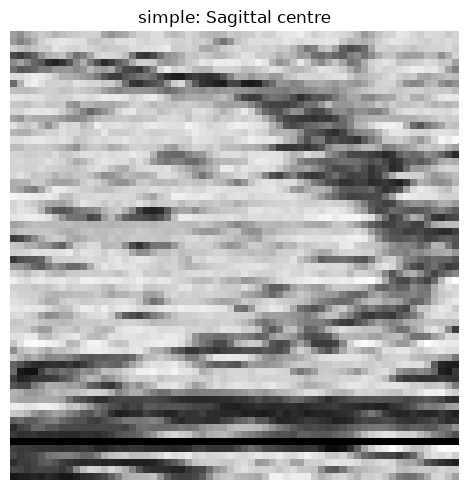

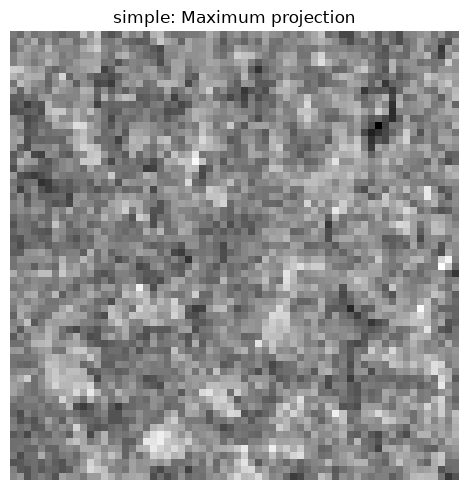

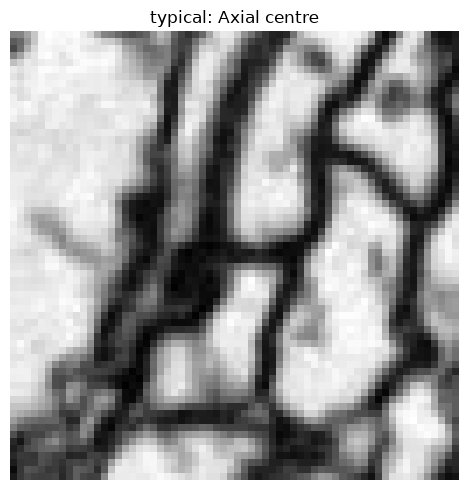

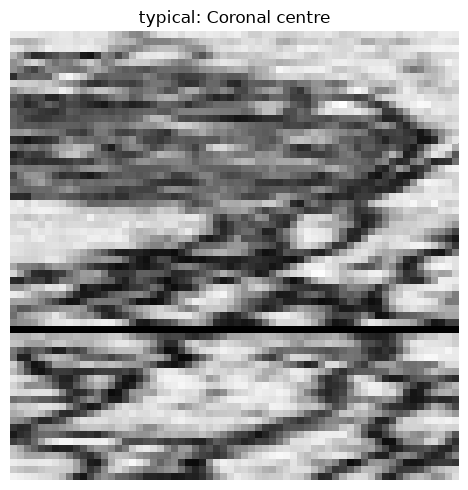

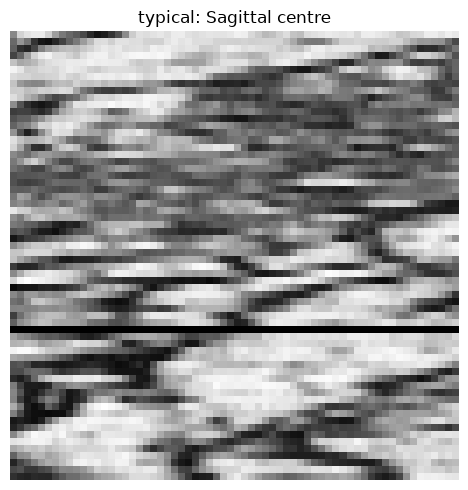

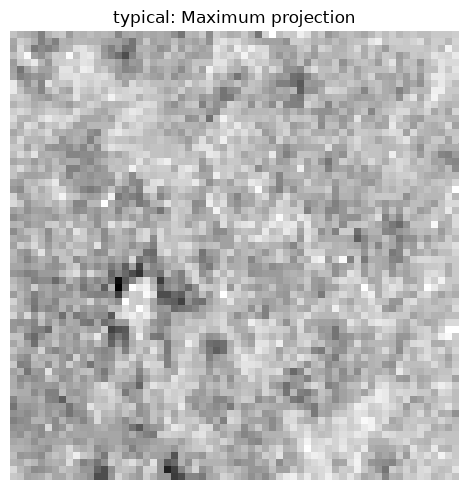

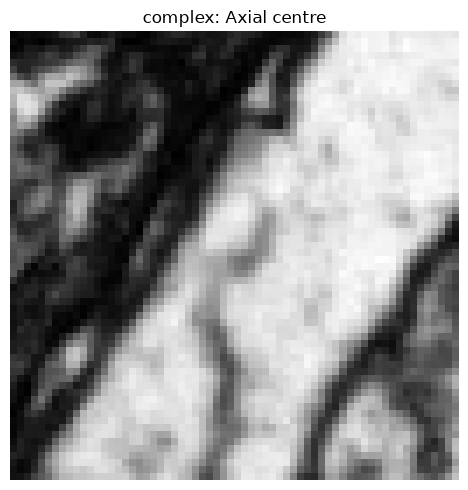

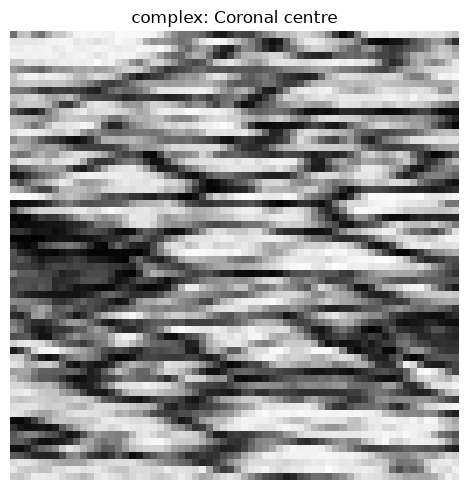

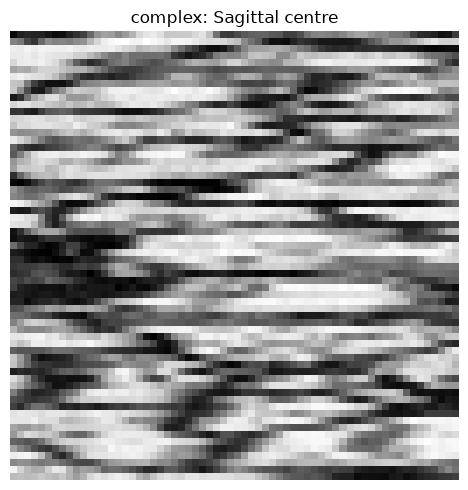

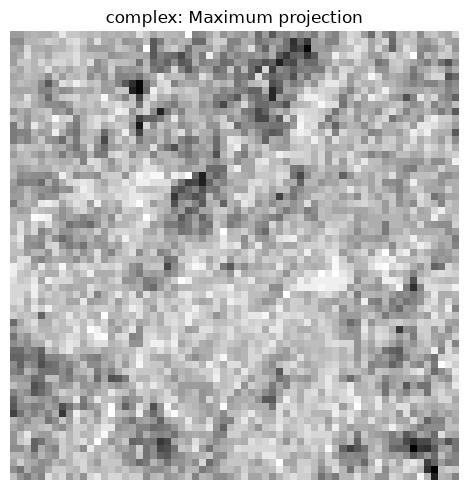

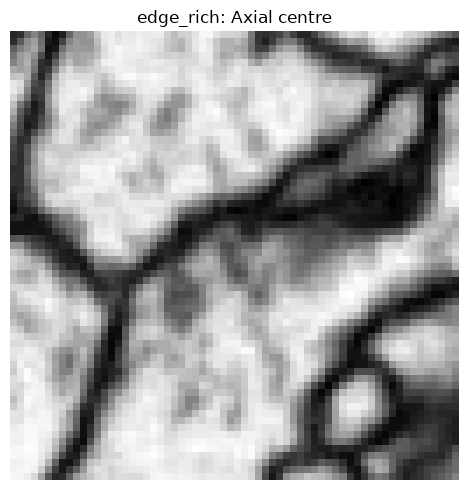

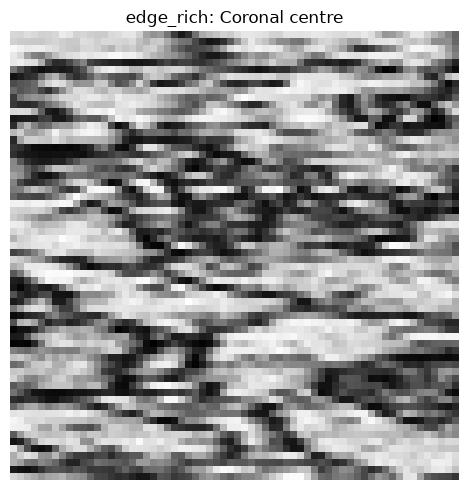

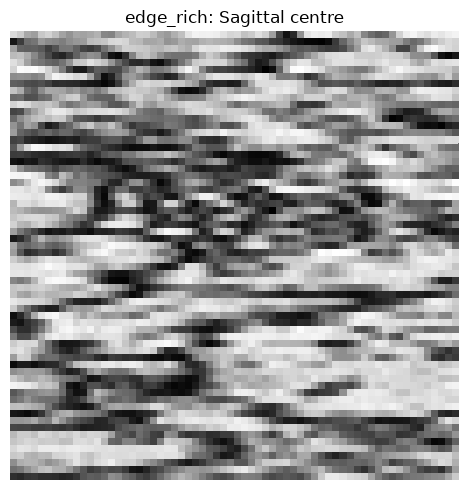

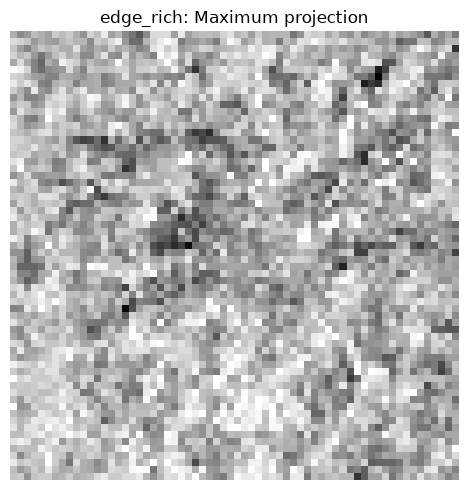

In [50]:
for category in selected_df["category"]:
    volume = np.load(selected_dir / f"{category}_normalized.npy")
    zc, yc, xc = [s // 2 for s in volume.shape]

    views = [
        ("Axial centre", volume[zc]),
        ("Coronal centre", volume[:, yc, :]),
        ("Sagittal centre", volume[:, :, xc]),
        ("Maximum projection", volume.max(axis=0)),
    ]

    for title, image in views:
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(image, cmap="gray")
        ax.set_title(f"{category}: {title}")
        ax.axis("off")
        fig.tight_layout()
        fig.savefig(
            selected_dir / f"{category}_{title.lower().replace(' ', '_')}.png",
            dpi=180,
            bbox_inches="tight",
        )
        plt.show()

## Interpretation and use

Use these four selected blocks as a pilot study only. For the final paper,
expand the Gaussian-versus-SIREN rate–distortion experiment to more blocks
sampled from the complete feature distribution.

Recommended compression evaluation per block:

- PSNR;
- SSIM;
- LPIPS as a supplementary metric;
- gradient error;
- representation size in bytes;
- compression ratio;
- training time;
- reconstruction/decode time.

In [ ]:
# analyse the results above
# 
